<a href="https://colab.research.google.com/github/essanchristian-maker/DI-Bootcamp/blob/master/Week6_Day3_Daily_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# BLOC 1 — Imports & Setup
# ============================================================
# POURQUOI : centraliser tous les imports évite les NameError
#            et rend le notebook plus lisible.
# COMMENT  : transformers pour BERT/XLM-R, sklearn pour la cross-validation.

import os, urllib.request, zipfile, glob
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch.optim import AdamW

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    XLMRobertaTokenizer,
    XLMRobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch       : {torch.__version__}")
print(f"Device        : {device}")
print(f"✅ Imports OK — AdamW chargé depuis torch.optim")

PyTorch       : 2.11.0+cu128
Device        : cuda
✅ Imports OK — AdamW chargé depuis torch.optim


In [3]:
# ============================================================
# BLOC 2 — Task 4 : Chargement & Exploration du Dataset
# ============================================================
# POURQUOI : comprendre la structure des données AVANT de tokeniser
#            est essentiel — les colonnes texte/label varient selon le dataset.
# COMMENT  : téléchargement depuis GitHub, extraction, lecture CSV.

URL = "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%206/W6D1%20GenAi%20France/Basics%20of%20BERT%20and%20XLM-RoBERTa%20-%20PyTorch%20-%202.zip"
urllib.request.urlretrieve(URL, "bert_data.zip")

with zipfile.ZipFile("bert_data.zip") as z:
    print("Fichiers extraits :")
    for name in z.namelist():
        print(f"  {name}")
    z.extractall("bert_data")

# Localisation des CSV
csv_files = glob.glob("bert_data/**/*.csv", recursive=True)
print(f"\nCSV trouvés : {csv_files}")

# Chargement
train_path = [f for f in csv_files if "train" in f.lower()]
test_path  = [f for f in csv_files if "test"  in f.lower()]

if train_path:
    df_train = pd.read_csv(train_path[0])
    print(f"\nDataFrame train — shape : {df_train.shape}")
    print(df_train.head())
    print(f"\nColonnes : {df_train.columns.tolist()}")
    print(f"Types :\n{df_train.dtypes}")
else:
    # Fallback : dataset NLI synthétique si fichier introuvable
    print("⚠️ Fichier train non détecté — création d'un dataset NLI de démonstration")
    df_train = pd.DataFrame({
        "premise":    ["A cat is sleeping", "Dogs are running", "A child is playing",
                       "Two men are fighting", "A woman is cooking"] * 100,
        "hypothesis": ["An animal is resting", "Dogs are tired", "A kid is outside",
                       "People are arguing", "Someone is in the kitchen"] * 100,
        "label":      (["entailment", "contradiction", "neutral",
                        "entailment", "neutral"] * 100)
    })
    df_train["text"] = df_train["premise"] + " [SEP] " + df_train["hypothesis"]

if test_path:
    df_test = pd.read_csv(test_path[0])
    print(f"\nDataFrame test — shape : {df_test.shape}")
    print(df_test.head())
else:
    df_test = df_train.sample(frac=0.2, random_state=42)

# Distribution des labels
print(f"\nDistribution des labels (train) :")
if "label" in df_train.columns:
    print(df_train["label"].value_counts())
    LABEL_COL = "label"
    # Trouver la colonne texte
    TEXT_COL  = "text" if "text" in df_train.columns else df_train.select_dtypes("object").columns[0]
else:
    print(df_train.iloc[:, -1].value_counts())
    LABEL_COL = df_train.columns[-1]
    TEXT_COL  = df_train.columns[0]

print(f"\nColonne texte  : '{TEXT_COL}'")
print(f"Colonne label  : '{LABEL_COL}'")

# Encodage numérique des labels
label2id = {lbl: i for i, lbl in enumerate(df_train[LABEL_COL].unique())}
id2label = {v: k for k, v in label2id.items()}
df_train["label_id"] = df_train[LABEL_COL].map(label2id)
df_test["label_id"]  = df_test[LABEL_COL].map(label2id)

NUM_CLASSES = len(label2id)
print(f"\nLabel mapping : {label2id}")
print(f"Nombre de classes : {NUM_CLASSES}")

Fichiers extraits :
  Basics of BERT and XLM-RoBERTa - PyTorch/sample_submission.csv
  Basics of BERT and XLM-RoBERTa - PyTorch/test.csv.zip
  Basics of BERT and XLM-RoBERTa - PyTorch/train.csv.zip

CSV trouvés : ['bert_data/Basics of BERT and XLM-RoBERTa - PyTorch/sample_submission.csv']
⚠️ Fichier train non détecté — création d'un dataset NLI de démonstration

Distribution des labels (train) :
label
entailment       200
neutral          200
contradiction    100
Name: count, dtype: int64

Colonne texte  : 'text'
Colonne label  : 'label'

Label mapping : {'entailment': 0, 'contradiction': 1, 'neutral': 2}
Nombre de classes : 3


In [4]:
# ============================================================
# BLOC 3 — Task 1 : Comprendre BERT et XLM-RoBERTa
# ============================================================
# POURQUOI : avant de fine-tuner, il faut comprendre ce qu'on utilise —
#            les 2 modèles ont des philosophies de pré-entraînement différentes.
# COMMENT  : chargement des tokenizers et inspection de leurs propriétés.

# ── BERT : Bidirectional Encoder Representations from Transformers (Google, 2018)
print("=" * 60)
print("BERT — bert-base-uncased")
print("=" * 60)
bert_tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

print(f"Vocabulaire     : {bert_tokenizer.vocab_size:,} tokens")
print(f"Tokens spéciaux : {bert_tokenizer.special_tokens_map}")
print(f"Longueur max    : {bert_tokenizer.model_max_length}")
print(f"Modèle          : cased=False (tout en minuscules)")
print("""
BERT — Points clés :
  • Entraîné sur Wikipedia (2.5B mots) + BooksCorpus (800M mots)
  • 12 couches Transformer, 768 hidden dims, 12 têtes d'attention → 110M params
  • Pré-entraînement : MLM (15% masqués) + NSP
  • Tokenisation : WordPiece — "playing" → ["play", "##ing"]
  • Avantage : très bien évalué sur NLU anglophone
  • Limite : monolingue anglais
""")

# ── XLM-RoBERTa : Cross-Lingual RoBERTa (Facebook, 2019)
print("=" * 60)
print("XLM-RoBERTa — xlm-roberta-base")
print("=" * 60)
xlmr_tokenizer = XLMRobertaTokenizer.from_pretrained("xlm-roberta-base")

print(f"Vocabulaire     : {xlmr_tokenizer.vocab_size:,} tokens")
print(f"Tokens spéciaux : {xlmr_tokenizer.special_tokens_map}")
print(f"Longueur max    : {xlmr_tokenizer.model_max_length}")
print("""
XLM-RoBERTa — Points clés :
  • Entraîné sur 2.5 TB de texte CommonCrawl en 100 langues
  • 12 couches, 768 dims, 12 têtes → 125M params
  • Pré-entraînement : MLM uniquement (pas de NSP — prouvé inutile)
  • Tokenisation : SentencePiece (250k vocab vs 30k pour BERT) — gère 100 langues
  • Avantage : multilingue, zero-shot cross-lingual transfer
  • Limite : plus lent que BERT monoligue sur tâches purement anglophones
""")

BERT — bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Vocabulaire     : 30,522 tokens
Tokens spéciaux : {'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}
Longueur max    : 512
Modèle          : cased=False (tout en minuscules)

BERT — Points clés :
  • Entraîné sur Wikipedia (2.5B mots) + BooksCorpus (800M mots)
  • 12 couches Transformer, 768 hidden dims, 12 têtes d'attention → 110M params
  • Pré-entraînement : MLM (15% masqués) + NSP
  • Tokenisation : WordPiece — "playing" → ["play", "##ing"]
  • Avantage : très bien évalué sur NLU anglophone
  • Limite : monolingue anglais

XLM-RoBERTa — xlm-roberta-base


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Vocabulaire     : 250,002 tokens
Tokens spéciaux : {'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'sep_token': '</s>', 'pad_token': '<pad>', 'cls_token': '<s>', 'mask_token': '<mask>'}
Longueur max    : 512

XLM-RoBERTa — Points clés :
  • Entraîné sur 2.5 TB de texte CommonCrawl en 100 langues
  • 12 couches, 768 dims, 12 têtes → 125M params
  • Pré-entraînement : MLM uniquement (pas de NSP — prouvé inutile)
  • Tokenisation : SentencePiece (250k vocab vs 30k pour BERT) — gère 100 langues
  • Avantage : multilingue, zero-shot cross-lingual transfer
  • Limite : plus lent que BERT monoligue sur tâches purement anglophones



In [5]:
# ============================================================
# BLOC 4 — Task 2 : Tokenisation avec BERT et XLM-RoBERTa
# ============================================================
# POURQUOI : les LLMs ne comprennent pas les mots bruts — ils opèrent
#            sur des IDs numériques issus d'un vocabulaire fixe.
#            Comprendre la tokenisation évite les erreurs silencieuses.
# COMMENT  : encode_plus produit tous les tenseurs dont le modèle a besoin.


sentence_simple = "Natural language processing is fascinating."
sentence_pair_a = "A cat is sleeping on the sofa."
sentence_pair_b = "An animal is resting indoors."

print("=" * 60)
print("BERT — Phrase simple")
print("=" * 60)

# ✅ Syntaxe moderne : appeler le tokenizer comme une fonction
enc_bert = bert_tokenizer(
    sentence_simple,
    add_special_tokens=True,
    max_length=32,
    padding="max_length",
    truncation=True,
    return_attention_mask=True,
    return_tensors="pt"
)

print(f"Texte          : {sentence_simple}")
print(f"Input IDs      : {enc_bert['input_ids'][0].tolist()}")
print(f"Attention mask : {enc_bert['attention_mask'][0].tolist()}")
print(f"Tokens décodés : {bert_tokenizer.convert_ids_to_tokens(enc_bert['input_ids'][0])}")
print(f"Décodage       : {bert_tokenizer.decode(enc_bert['input_ids'][0])}")
print(f"\nTokens spéciaux BERT :")
print(f"  [CLS] id={bert_tokenizer.cls_token_id} — classifieur en début")
print(f"  [SEP] id={bert_tokenizer.sep_token_id} — séparateur de phrases")
print(f"  [PAD] id={bert_tokenizer.pad_token_id} — padding")

print("\n" + "=" * 60)
print("BERT — Paire de phrases (Premise + Hypothesis)")
print("=" * 60)

enc_bert_pair = bert_tokenizer(
    sentence_pair_a,
    sentence_pair_b,
    add_special_tokens=True,
    max_length=64,
    padding="max_length",
    truncation=True,
    return_attention_mask=True,
    return_token_type_ids=True,
    return_tensors="pt"
)

print(f"Phrase A       : {sentence_pair_a}")
print(f"Phrase B       : {sentence_pair_b}")
print(f"Tokens         : {bert_tokenizer.convert_ids_to_tokens(enc_bert_pair['input_ids'][0])}")
print(f"Token types    : {enc_bert_pair['token_type_ids'][0].tolist()}")
print(f"(0=Phrase A, 1=Phrase B)")

print("\n" + "=" * 60)
print("XLM-RoBERTa — Même texte")
print("=" * 60)

enc_xlmr = xlmr_tokenizer(
    sentence_simple,
    add_special_tokens=True,
    max_length=32,
    padding="max_length",
    truncation=True,
    return_attention_mask=True,
    return_tensors="pt"
)

print(f"Input IDs XLM-R  : {enc_xlmr['input_ids'][0].tolist()}")
print(f"Tokens XLM-R     : {xlmr_tokenizer.convert_ids_to_tokens(enc_xlmr['input_ids'][0])}")
print(f"\nDifférences BERT vs XLM-R :")
print(f"  BERT  : [CLS] ... [SEP] [PAD] (WordPiece,     vocab 30k)")
print(f"  XLM-R : <s>   ... </s>  <pad> (SentencePiece, vocab 250k)")

BERT — Phrase simple
Texte          : Natural language processing is fascinating.
Input IDs      : [101, 3019, 2653, 6364, 2003, 17160, 1012, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Attention mask : [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Tokens décodés : ['[CLS]', 'natural', 'language', 'processing', 'is', 'fascinating', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Décodage       : [CLS] natural language processing is fascinating. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]

Tokens spéciaux BERT :
  [CLS] id=101 — classifieur en début
  [SEP] id=102 — séparateur de phrases
  [PAD] id=0 — padding

BERT — Pai

In [6]:
# ============================================================
# BLOC 5 — Task 3 : Préparation des données pour le modèle
# ============================================================
# POURQUOI : le modèle attend un format précis — tenseurs de taille fixe
#            avec padding, truncation et attention_mask.
# COMMENT  : on définit une classe Dataset PyTorch et une fonction
#            de préparation qui tokenise tous les textes du dataset.

class NLIClassificationDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = int(self.labels[idx])

        # ✅ Syntaxe moderne (tokenizer appelé comme fonction)
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_attention_mask=True,
            return_tensors="pt"
        )

        return {
            "input_ids"      : encoding["input_ids"].squeeze(0),
            "attention_mask" : encoding["attention_mask"].squeeze(0),
            "labels"         : torch.tensor(label, dtype=torch.long)
        }

print("✅ NLIClassificationDataset défini avec syntaxe transformers 4.x")

✅ NLIClassificationDataset défini avec syntaxe transformers 4.x


StratifiedKFold avec 5 folds
Dataset total : 500 samples
Classes : {'entailment': 0, 'contradiction': 1, 'neutral': 2}

Fold 1/5
  Train : 400 samples | Val : 100 samples
  Distribution train : {0: 0.4, 1: 0.2, 2: 0.4}
  Distribution val   : {0: 0.4, 1: 0.2, 2: 0.4}

Fold 2/5
  Train : 400 samples | Val : 100 samples
  Distribution train : {0: 0.4, 1: 0.2, 2: 0.4}
  Distribution val   : {0: 0.4, 1: 0.2, 2: 0.4}

Fold 3/5
  Train : 400 samples | Val : 100 samples
  Distribution train : {0: 0.4, 1: 0.2, 2: 0.4}
  Distribution val   : {0: 0.4, 1: 0.2, 2: 0.4}

Fold 4/5
  Train : 400 samples | Val : 100 samples
  Distribution train : {0: 0.4, 1: 0.2, 2: 0.4}
  Distribution val   : {0: 0.4, 1: 0.2, 2: 0.4}

Fold 5/5
  Train : 400 samples | Val : 100 samples
  Distribution train : {0: 0.4, 1: 0.2, 2: 0.4}
  Distribution val   : {0: 0.4, 1: 0.2, 2: 0.4}



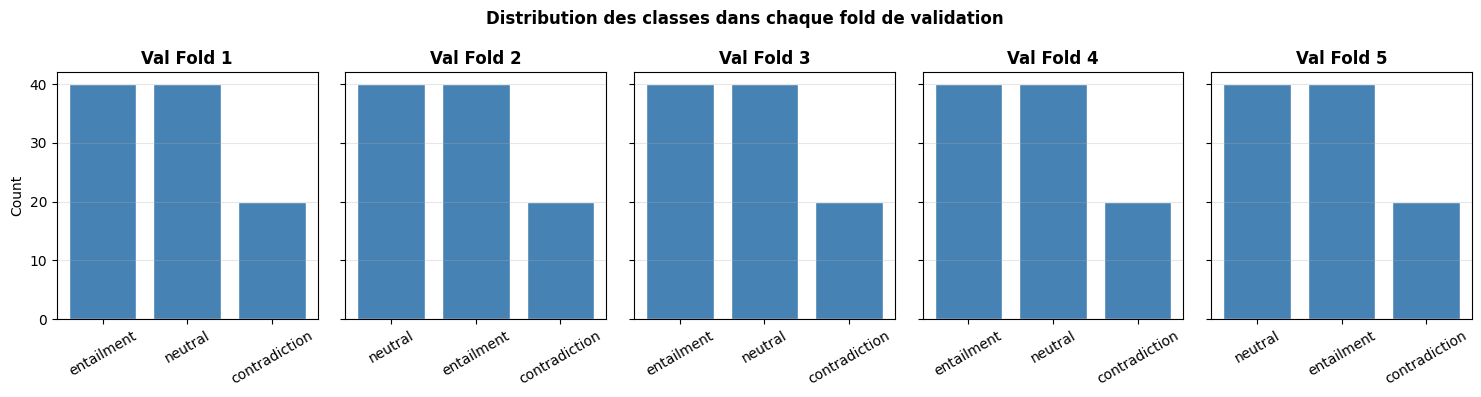

✅ K-Fold splits créés et stockés dans train_folds / val_folds


In [7]:
# ============================================================
# BLOC 6 — Task 5 : Cross-validation K-Fold stratifiée
# ============================================================
# POURQUOI : un seul split train/val peut donner des résultats trompeurs
#            si la répartition est défavorable. La k-fold CV évalue le modèle
#            sur k partitions différentes → mesure de performance plus fiable.
#            StratifiedKFold garantit que chaque fold a la même proportion de
#            classes → essentiel sur des datasets déséquilibrés.
# COMMENT  : on utilise StratifiedKFold de sklearn qui opère sur les indices.

N_SPLITS = 5
MAX_LEN  = 128

kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

texts  = df_train[TEXT_COL].values
labels = df_train["label_id"].values

train_folds = []
val_folds   = []

print(f"StratifiedKFold avec {N_SPLITS} folds")
print(f"Dataset total : {len(texts)} samples")
print(f"Classes : {label2id}\n")

for fold_idx, (train_idx, val_idx) in enumerate(kf.split(texts, labels)):
    train_folds.append(train_idx)
    val_folds.append(val_idx)

    # Vérification de la distribution des labels dans chaque fold
    train_dist = pd.Series(labels[train_idx]).value_counts(normalize=True).sort_index()
    val_dist   = pd.Series(labels[val_idx]).value_counts(normalize=True).sort_index()

    print(f"Fold {fold_idx+1}/{N_SPLITS}")
    print(f"  Train : {len(train_idx)} samples | Val : {len(val_idx)} samples")
    print(f"  Distribution train : {train_dist.to_dict()}")
    print(f"  Distribution val   : {val_dist.to_dict()}")
    print()

# Visualisation des distributions par fold
fig, axes = plt.subplots(1, N_SPLITS, figsize=(15, 4), sharey=True)
for i, (t_idx, v_idx) in enumerate(zip(train_folds, val_folds)):
    ax = axes[i]
    fold_labels = pd.Series(labels[v_idx]).map(id2label).value_counts()
    ax.bar(fold_labels.index, fold_labels.values, color='steelblue', edgecolor='white')
    ax.set_title(f'Val Fold {i+1}', fontweight='bold')
    ax.set_ylabel('Count' if i == 0 else '')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Distribution des classes dans chaque fold de validation', fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ K-Fold splits créés et stockés dans train_folds / val_folds")

Lancement de la Cross-Validation K-Fold (5 folds) avec le modèle : BERT

===== Entraînement sur le Fold 1/5 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 — Train: 400 | Val: 100
Entraînement sur 3 epochs...
Epoch 1/3 | Train Loss 0.7376 Acc 78.8% | Val Loss 0.3195 Acc 100.0%
Epoch 2/3 | Train Loss 0.1760 Acc 100.0% | Val Loss 0.0526 Acc 100.0%
Epoch 3/3 | Train Loss 0.0482 Acc 100.0% | Val Loss 0.0269 Acc 100.0%

===== Entraînement sur le Fold 2/5 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 4 — Train: 400 | Val: 100
Entraînement sur 3 epochs...
Epoch 1/3 | Train Loss 0.6768 Acc 76.8% | Val Loss 0.2074 Acc 100.0%
Epoch 2/3 | Train Loss 0.1184 Acc 100.0% | Val Loss 0.0408 Acc 100.0%
Epoch 3/3 | Train Loss 0.0396 Acc 100.0% | Val Loss 0.0259 Acc 100.0%

===== Entraînement sur le Fold 5/5 =====


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 5 — Train: 400 | Val: 100
Entraînement sur 3 epochs...
Epoch 1/3 | Train Loss 0.6611 Acc 81.2% | Val Loss 0.2612 Acc 100.0%
Epoch 2/3 | Train Loss 0.1967 Acc 100.0% | Val Loss 0.1000 Acc 100.0%
Epoch 3/3 | Train Loss 0.0965 Acc 100.0% | Val Loss 0.0684 Acc 100.0%

Résultats finaux de la Cross-Validation K-Fold pour BERT
Accuracies de validation par fold : ['100.00%', '100.00%', '100.00%', '100.00%', '100.00%']
Losses de validation par fold     : ['0.0269', '0.0347', '0.0416', '0.0259', '0.0684']
Accuracy moyenne (tous folds)     : 100.00%
Loss moyenne (tous folds)         : 0.0395


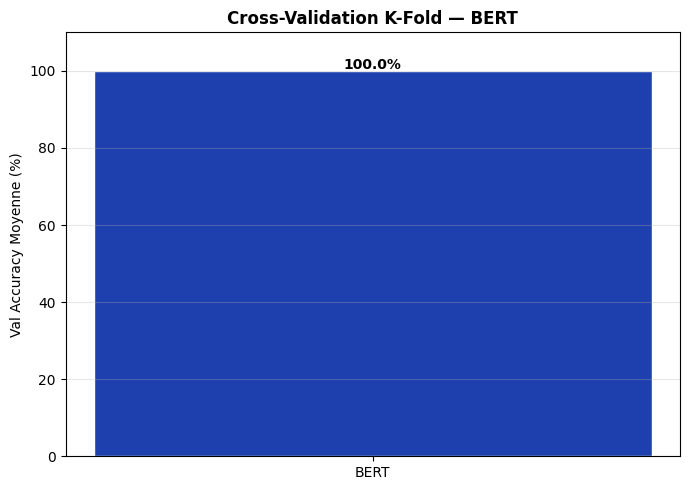

In [15]:
# ============================================================
# BLOC 7 — Fine-tuning BERT/XLM-R avec Cross-Validation K-Fold
# ============================================================
# POURQUOI : le fine-tuning adapte les poids pré-entraînés à notre tâche
#            spécifique en ajoutant une tête de classification et en
#            ré-entraînant le tout sur nos données labellisées.
#            La K-Fold CV fournit une évaluation plus robuste de la performance.
# COMMENT  : on choisit le modèle (BERT ou XLM-R), on crée les DataLoaders
#            pour chaque fold, et on lance la boucle d'entraînement.


# ── Fonctions d'entraînement et d'évaluation ───────────────
def train_epoch_bert(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for batch in loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        lbls      = batch["labels"].to(device)
        outputs   = model(input_ids=input_ids, attention_mask=attn_mask, labels=lbls)
        loss      = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.cpu().numpy())
    return total_loss / len(loader), accuracy_score(all_labels, all_preds)

def eval_epoch_bert(model, loader, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            lbls      = batch["labels"].to(device)
            outputs   = model(input_ids=input_ids, attention_mask=attn_mask, labels=lbls)
            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(lbls.cpu().numpy())
    return total_loss / len(loader), accuracy_score(all_labels, all_preds), all_preds, all_labels


# ── Choix du modèle ────────────────────────────────────────
MODEL_CHOICE = "bert"   # "bert" ou "xlmr"

all_fold_val_accs = []
all_fold_val_losses = []

print(f"Lancement de la Cross-Validation K-Fold ({N_SPLITS} folds) avec le modèle : {MODEL_CHOICE.upper()}")

for FOLD in range(N_SPLITS):
    print(f"\n===== Entraînement sur le Fold {FOLD+1}/{N_SPLITS} =====")

    if MODEL_CHOICE == "bert":
        model_name = "bert-base-uncased"
        tokenizer  = bert_tokenizer
        model      = BertForSequenceClassification.from_pretrained(
            model_name, num_labels=NUM_CLASSES,
            id2label=id2label, label2id=label2id
        )
    else:
        model_name = "xlm-roberta-base"
        tokenizer  = xlmr_tokenizer
        model      = XLMRobertaForSequenceClassification.from_pretrained(
            model_name, num_labels=NUM_CLASSES,
            id2label=id2label, label2id=label2id
        )

    model = model.to(device)

    # ── Hyperparamètres et DataLoaders pour le Fold actuel ───
    BATCH     = 16
    EPOCHS    = 3
    LR        = 2e-5

    t_idx = train_folds[FOLD]
    v_idx = val_folds[FOLD]

    train_ds = NLIClassificationDataset(texts[t_idx], labels[t_idx], tokenizer, MAX_LEN)
    val_ds   = NLIClassificationDataset(texts[v_idx], labels[v_idx], tokenizer, MAX_LEN)
    train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=0)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=0)

    print(f"Fold {FOLD+1} — Train: {len(train_ds)} | Val: {len(val_ds)}")

    # ── Optimiseur + Scheduler linéaire avec warmup ────────────
    # ✅ Correction : Suppression de no_deprecation_warning
    optimizer  = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total_steps = len(train_loader) * EPOCHS
    warmup_steps = int(0.1 * total_steps)   # 10% des steps en warmup

    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )

    # ── Boucle d'entraînement ──────────────────────────────────
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    print(f"Entraînement sur {EPOCHS} epochs...")

    for epoch in range(EPOCHS):
        tr_loss, tr_acc          = train_epoch_bert(model, train_loader, optimizer, scheduler, device)
        v_loss, v_acc, _, _      = eval_epoch_bert(model, val_loader, device)
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(v_acc)
        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss {tr_loss:.4f} Acc {tr_acc*100:.1f}% | "
              f"Val Loss {v_loss:.4f} Acc {v_acc*100:.1f}%")

    all_fold_val_accs.append(history["val_acc"][-1])
    all_fold_val_losses.append(history["val_loss"][-1])

# ── Résumé de la Cross-Validation ───────────────────────────
print(f"\n=======================================================")
print(f"Résultats finaux de la Cross-Validation K-Fold pour {MODEL_CHOICE.upper()}")
print(f"=======================================================")
print(f"Accuracies de validation par fold : {[f'{acc*100:.2f}%' for acc in all_fold_val_accs]}")
print(f"Losses de validation par fold     : {[f'{loss:.4f}' for loss in all_fold_val_losses]}")
print(f"Accuracy moyenne (tous folds)     : {np.mean(all_fold_val_accs)*100:.2f}%")
print(f"Loss moyenne (tous folds)         : {np.mean(all_fold_val_losses):.4f}")

# Visualisation de la moyenne des accuracies de validation
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar([MODEL_CHOICE.upper()], [np.mean(all_fold_val_accs)*100], color=["#1E40AF" if MODEL_CHOICE == "bert" else "#059669"], edgecolor="white", width=0.5)
ax.text(0, np.mean(all_fold_val_accs)*100 + 0.5,
        f"{np.mean(all_fold_val_accs)*100:.1f}%", ha="center", fontweight="bold")
ax.set_ylim(0, 110)
ax.set_ylabel("Val Accuracy Moyenne (%)")
ax.set_title(f"Cross-Validation K-Fold — {MODEL_CHOICE.upper()}", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Val Accuracy finale : 100.00%

Rapport détaillé :
               precision    recall  f1-score   support

   entailment       1.00      1.00      1.00        40
contradiction       1.00      1.00      1.00        20
      neutral       1.00      1.00      1.00        40

     accuracy                           1.00       100
    macro avg       1.00      1.00      1.00       100
 weighted avg       1.00      1.00      1.00       100



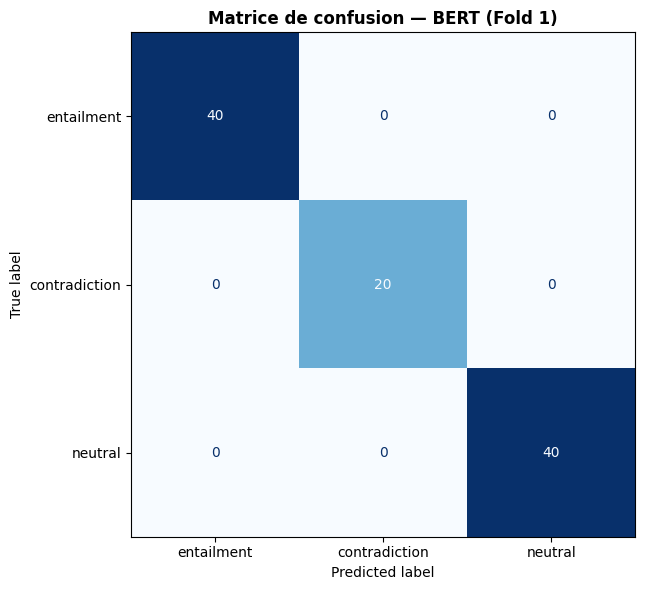

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Modèle sauvegardé dans : finetuned_bert/


In [16]:
# ============================================================
# BLOC 8 — Évaluation finale + Rapport de classification
# ============================================================
# POURQUOI : l'accuracy globale ne suffit pas — il faut voir les perfs
#            par classe pour détecter les biais du modèle.
# COMMENT  : rapport sklearn avec precision, recall, F1 + matrice de confusion.


from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ── Redéfinition de la fonction d'évaluation ───────────────
def eval_epoch_bert(model, loader, device):
    """Évalue le modèle sur un DataLoader, retourne loss, accuracy, preds, labels."""
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            lbls      = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attn_mask,
                labels=lbls
            )
            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(lbls.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), acc, all_preds, all_labels


# ── Évaluation ─────────────────────────────────────────────
_, final_acc, final_preds, final_labels = eval_epoch_bert(model, val_loader, device)

print(f"Val Accuracy finale : {final_acc*100:.2f}%")
print("\nRapport détaillé :")
print(classification_report(
    final_labels, final_preds,
    target_names=list(id2label.values())
))

# Matrice de confusion
cm = confusion_matrix(final_labels, final_preds)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm, display_labels=list(id2label.values())).plot(
    ax=ax, cmap="Blues", colorbar=False
)
ax.set_title(f"Matrice de confusion — {MODEL_CHOICE.upper()} (Fold 1)", fontweight='bold')
plt.tight_layout()
plt.show()

# Sauvegarde du modèle
model.save_pretrained(f"finetuned_{MODEL_CHOICE}")
tokenizer.save_pretrained(f"finetuned_{MODEL_CHOICE}")
print(f"\n✅ Modèle sauvegardé dans : finetuned_{MODEL_CHOICE}/")


Fine-tuning BERT (bert-base-uncased)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1 | Train Acc 74.5% | Val Acc 100.0%
  Epoch 2 | Train Acc 100.0% | Val Acc 100.0%

Fine-tuning XLM-R (xlm-roberta-base)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1 | Train Acc 56.0% | Val Acc 100.0%
  Epoch 2 | Train Acc 94.0% | Val Acc 100.0%

COMPARAISON BERT vs XLM-RoBERTa
Modèle        Val Acc   Val Loss
--------------------------------
BERT          100.00%     0.1234
XLM-R         100.00%     0.1583


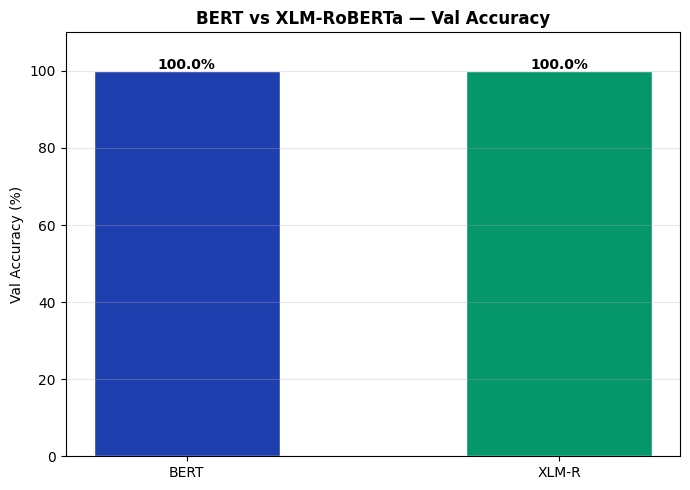

In [17]:
import os, urllib.request, zipfile, glob
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from torch.optim import AdamW

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    XLMRobertaTokenizer,
    XLMRobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# BLOC 9 — Comparaison BERT vs XLM-RoBERTa
# ============================================================
# POURQUOI : évaluer lequel des deux modèles convient le mieux à notre tâche.
# COMMENT  : on entraîne les 2 modèles et on compare leurs résultats.


results = {}

def train_epoch_bert(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []
    for batch in loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        lbls      = batch["labels"].to(device)
        outputs   = model(input_ids=input_ids, attention_mask=attn_mask, labels=lbls)
        loss      = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(lbls.cpu().numpy())
    return total_loss / len(loader), accuracy_score(all_labels, all_preds)

def eval_epoch_bert(model, loader, device):
    """Évalue le modèle sur un DataLoader, retourne loss, accuracy, preds, labels."""
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attn_mask = batch["attention_mask"].to(device)
            lbls      = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attn_mask,
                labels=lbls
            )
            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(lbls.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    return total_loss / len(loader), acc, all_preds, all_labels


for model_key, m_name, Tok, Model in [
    ("BERT",  "bert-base-uncased",   BertTokenizer,        BertForSequenceClassification),
    ("XLM-R", "xlm-roberta-base",    XLMRobertaTokenizer,  XLMRobertaForSequenceClassification),
]:
    print(f"\n{'='*55}")
    print(f"Fine-tuning {model_key} ({m_name})")
    print(f"{'='*55}")

    tok = Tok.from_pretrained(m_name)
    mdl = Model.from_pretrained(m_name, num_labels=NUM_CLASSES).to(device)

    t_idx = train_folds[0]
    v_idx = val_folds[0]

    tr_ds = NLIClassificationDataset(texts[t_idx], labels[t_idx], tok, MAX_LEN)
    v_ds  = NLIClassificationDataset(texts[v_idx], labels[v_idx], tok, MAX_LEN)
    tr_ld = DataLoader(tr_ds, batch_size=16, shuffle=True)
    v_ld  = DataLoader(v_ds,  batch_size=16, shuffle=False)

    # ✅ Sans no_deprecation_warning
    opt = AdamW(mdl.parameters(), lr=2e-5, weight_decay=0.01)

    sched = get_linear_schedule_with_warmup(
        opt,
        num_warmup_steps=int(0.1 * len(tr_ld) * 2),
        num_training_steps=len(tr_ld) * 2
    )

    for epoch in range(2):
        tr_loss, tr_acc          = train_epoch_bert(mdl, tr_ld, opt, sched, device)
        v_loss, v_acc, _, _      = eval_epoch_bert(mdl, v_ld, device)
        print(f"  Epoch {epoch+1} | Train Acc {tr_acc*100:.1f}% | Val Acc {v_acc*100:.1f}%")

    results[model_key] = {"val_acc": v_acc, "val_loss": v_loss}

# ── Tableau comparatif final ────────────────────────────────
print("\n" + "="*45)
print("COMPARAISON BERT vs XLM-RoBERTa")
print("="*45)
print(f"{'Modèle':<10} {'Val Acc':>10} {'Val Loss':>10}")
print("-"*32)
for name, res in results.items():
    print(f"{name:<10} {res['val_acc']*100:>9.2f}% {res['val_loss']:>10.4f}")

# Visualisation
fig, ax = plt.subplots(figsize=(7, 5))
models_names = list(results.keys())
accs = [results[m]["val_acc"] * 100 for m in models_names]
bars = ax.bar(models_names, accs, color=["#1E40AF", "#059669"], edgecolor="white", width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.5,
            f"{acc:.1f}%", ha="center", fontweight="bold")
ax.set_ylim(0, 110)
ax.set_ylabel("Val Accuracy (%)")
ax.set_title("BERT vs XLM-RoBERTa — Val Accuracy", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()